
# 🚦 Low-bit Communication: Section 3 Method in PyTorch

This notebook is intentionally compact.

We will simulate **two devices** on one computer and implement the key idea:

> Select a few high-range feature columns to keep in high precision, quantize the rest to Int4, send the compressed tensors, dequantize, then sum.

No Gemma. No long experiment section. Just the core idea.



## 0. Setup


In [49]:

import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

def short_list(x, decimals=2):
    return [round(v, decimals) for v in x.detach().cpu().tolist()]

def short_matrix(x, decimals=2):
    return torch.round(x.detach().cpu(), decimals=decimals)

print("PyTorch:", torch.__version__)


PyTorch: 2.12.0



## 1. Why do we sum outputs in this setup?

Start with a tiny linear layer:

```python
X = [[2, 3]]
W = [[4, 5],
     [6, 7]]
```

The full computation is:

```text
X @ W = [2×4 + 3×6, 2×5 + 3×7]
      = [26, 31]
```

Now split the input dimension across two simulated devices:

```text
Device 1 gets:
X₁ = [2]
W₁ = [[4, 5]]

Device 2 gets:
X₂ = [3]
W₂ = [[6, 7]]
```

Each device computes a partial contribution:

```text
Device 1: X₁ @ W₁ = [8, 10]
Device 2: X₂ @ W₂ = [18, 21]
```

Then we sum:

```text
[8, 10] + [18, 21] = [26, 31]
```

This is why the paper writes the synchronized output as a sum of partial outputs.



<div style="background-color:#eefbea; border-left:6px solid #27ae60; padding:12px; border-radius:8px;">
<b>Key idea:</b> each device produces a partial contribution to the same output vector, so the outputs are summed.
</div>



## 2. Create a tiny tensor-parallel example

Now we use a slightly bigger toy example.

```text
S = number of tokens/examples
D = input feature dimension
E = output feature dimension
```

We keep everything small:

```text
S = 4
D = 4
E = 4
```

So:

```text
X shape = [4, 4]
W shape = [4, 4]
Y shape = [4, 4]
```


In [50]:

def split_input_dimension(X, W, num_devices=2):
    D = X.shape[1]
    assert D % num_devices == 0

    chunk = D // num_devices
    X_parts, W_parts = [], []

    for i in range(num_devices):
        start, end = i * chunk, (i + 1) * chunk
        X_parts.append(X[:, start:end])
        W_parts.append(W[start:end, :])

    return X_parts, W_parts


def tensor_parallel_sum_forward(X, W, num_devices=2):
    X_parts, W_parts = split_input_dimension(X, W, num_devices)
    partials = [x_i @ w_i for x_i, w_i in zip(X_parts, W_parts)]
    synced = sum(partials)
    return partials, synced


S, D, E = 4, 4, 4
num_devices = 2

X_demo = torch.tensor([
    [1.0,  0.5, -1.0,  2.0],
    [0.0, -1.0,  1.5,  1.0],
    [2.0,  1.0,  0.0, -0.5],
    [1.5, -0.5,  1.0,  0.0],
])

# Column 2 is intentionally large so calibration can discover it.
W_demo = torch.tensor([
    [ 1.0,  0.5,  8.0,  1.0],
    [ 0.0, -1.0, -6.0,  0.5],
    [ 1.0,  1.0,  7.0, -1.0],
    [-0.5,  0.0,  5.0,  1.0],
])

partials, Y_original_synced = tensor_parallel_sum_forward(X_demo, W_demo, num_devices=num_devices)
# Normal single-device computation, no tensor parallelism

Y_full_no_parallel = X_demo @ W_demo

print("Device 1 partial output Y^(1):")

print(short_matrix(partials[0]))

print("\nDevice 2 partial output Y^(2):")

print(short_matrix(partials[1]))

print("\nSynced output from tensor-parallel sum:")

print(short_matrix(Y_original_synced))

print("\nNormal output without tensor parallelism:")

print(short_matrix(Y_full_no_parallel))

print("\nDo they match?")

print(torch.allclose(Y_original_synced, Y_full_no_parallel))


Device 1 partial output Y^(1):
tensor([[ 1.0000,  0.0000,  5.0000,  1.2500],
        [ 0.0000,  1.0000,  6.0000, -0.5000],
        [ 2.0000,  0.0000, 10.0000,  2.5000],
        [ 1.5000,  1.2500, 15.0000,  1.2500]])

Device 2 partial output Y^(2):
tensor([[-2.0000, -1.0000,  3.0000,  3.0000],
        [ 1.0000,  1.5000, 15.5000, -0.5000],
        [ 0.2500,  0.0000, -2.5000, -0.5000],
        [ 1.0000,  1.0000,  7.0000, -1.0000]])

Synced output from tensor-parallel sum:
tensor([[-1.0000, -1.0000,  8.0000,  4.2500],
        [ 1.0000,  2.5000, 21.5000, -1.0000],
        [ 2.2500,  0.0000,  7.5000,  2.0000],
        [ 2.5000,  2.2500, 22.0000,  0.2500]])

Normal output without tensor parallelism:
tensor([[-1.0000, -1.0000,  8.0000,  4.2500],
        [ 1.0000,  2.5000, 21.5000, -1.0000],
        [ 2.2500,  0.0000,  7.5000,  2.0000],
        [ 2.5000,  2.2500, 22.0000,  0.2500]])

Do they match?
True



## 3. Calibration: track min/max over two tiny batches

The paper tracks min/max values over calibration sequences.

For each device and feature column, we compute:

```text
current_min = min value in that feature column
current_max = max value in that feature column
```

Then we update the stored values:

```text
tracked_min = (1 - gamma) × old_min + gamma × current_min
tracked_max = (1 - gamma) × old_max + gamma × current_max
```

In the real paper, they use many calibration sequences.  
Here, we use only **two tiny batches** so the algorithm is visible without making the notebook noisy.

Finally, we compute the symmetric range:

```text
R = 2 × max(abs(tracked_min), abs(tracked_max))
```


In [51]:

def symmetric_range_from_min_max(m, M):
        # We use a symmetric range around zero.
        # Example: min=-3, max=5 → use range [-5, 5], whose width is 10.
        # That is why we multiply the largest absolute value by 2.
    return 2 * torch.maximum(-m, M) # We use a symmetric range around zero.


def update_tracked_min_max(old_min, old_max, current_min, current_max, gamma=0.01):
    """Update tracked min/max using the paper's moving-average idea."""
    if old_min is None:
        return current_min, current_max

    new_min = (1 - gamma) * old_min + gamma * current_min
    new_max = (1 - gamma) * old_max + gamma * current_max
    return new_min, new_max


# We use two tiny calibration batches so the tracking algorithm is visible.
# Batch 1 initializes the tracked min/max.
# Batch 2 updates them using gamma.
calibration_batches = [
    X_demo,
    X_demo + torch.tensor([
        [ 0.2, -0.1,  0.0,  0.1],
        [ 0.1,  0.2, -0.1,  0.0],
        [-0.2,  0.0,  0.1, -0.1],
        [ 0.0,  0.1,  0.2,  0.0],
    ]),
]

gamma = 0.01

tracked_mins = [None for _ in range(num_devices)]
tracked_maxs = [None for _ in range(num_devices)]
print("tracked_mins",tracked_mins)

for batch_idx, X_calib in enumerate(calibration_batches):
    partials_calib, _ = tensor_parallel_sum_forward(
        X_calib,
        W_demo,
        num_devices=num_devices
    )

    print(f"Calibration batch {batch_idx + 1}")

    for device_idx, Y_i in enumerate(partials_calib):
        current_min = Y_i.min(dim=0).values
        current_max = Y_i.max(dim=0).values

        tracked_mins[device_idx], tracked_maxs[device_idx] = update_tracked_min_max(
            tracked_mins[device_idx],
            tracked_maxs[device_idx],
            current_min,
            current_max,
            gamma=gamma
        )

        print(f"  Device {device_idx + 1}")
        print("    current min:  ", short_list(current_min))
        print("    current max:  ", short_list(current_max))
        print("    tracked min:  ", short_list(tracked_mins[device_idx]))
        print("    tracked max:  ", short_list(tracked_maxs[device_idx]))

    print()

ranges = [
    symmetric_range_from_min_max(tracked_mins[i], tracked_maxs[i])
    for i in range(num_devices)
]

print("Final tracked symmetric ranges:")
for i, R_i in enumerate(ranges):
    print(f"Device {i+1} range R:", short_list(R_i))


tracked_mins [None, None]
Calibration batch 1
  Device 1
    current min:   [0.0, 0.0, 5.0, -0.5]
    current max:   [2.0, 1.25, 15.0, 2.5]
    tracked min:   [0.0, 0.0, 5.0, -0.5]
    tracked max:   [2.0, 1.25, 15.0, 2.5]
  Device 2
    current min:   [-2.0, -1.0, -2.5, -1.0]
    current max:   [1.0, 1.5, 15.5, 3.0]
    tracked min:   [-2.0, -1.0, -2.5, -1.0]
    tracked max:   [1.0, 1.5, 15.5, 3.0]

Calibration batch 2
  Device 1
    current min:   [0.1, -0.1, 5.6, -0.3]
    current max:   [1.8, 1.15, 14.4, 2.3]
    tracked min:   [0.0, -0.0, 5.01, -0.5]
    tracked max:   [2.0, 1.25, 14.99, 2.5]
  Device 2
    current min:   [-2.05, -1.0, -2.3, -1.2]
    current max:   [1.2, 1.4, 14.8, 3.1]
    tracked min:   [-2.0, -1.0, -2.5, -1.0]
    tracked max:   [1.0, 1.5, 15.49, 3.0]

Final tracked symmetric ranges:
Device 1 range R: [4.0, 2.5, 29.99, 5.0]
Device 2 range R: [4.0, 3.0, 30.99, 6.0]



## 4. Aggregate ranges across devices

The paper aggregates the range for each feature across devices:

```text
R̄ⱼ = Rⱼ^(1) + Rⱼ^(2)
```

This gives one score per feature.

A large score means:

> This feature is more dangerous to quantize.


Aggregated range per feature:
  Feature 0: 8.00
  Feature 1: 5.50
  Feature 2: 60.97
  Feature 3: 11.00


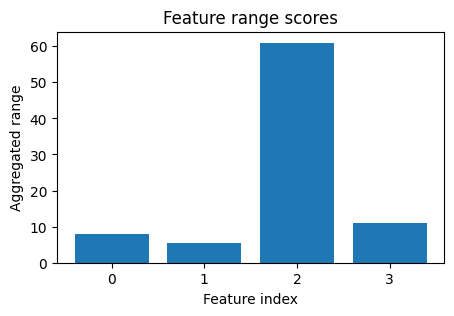

In [52]:

aggregated_range = sum(ranges)

print("Aggregated range per feature:")
for j, value in enumerate(aggregated_range):
    print(f"  Feature {j}: {value.item():.2f}")

plt.figure(figsize=(5, 3))
plt.bar(range(E), aggregated_range.numpy())
plt.xticks(range(E))
plt.xlabel("Feature index")
plt.ylabel("Aggregated range")
plt.title("Feature range scores")
plt.show()



## 5. Select the feature to keep in high precision

For the real paper, they keep a tiny fraction of features in BF16.

For this tiny notebook:

```text
E = 4
k = 1
```

So we keep only one feature column in high precision, and quantize the other three to Int4.


In [53]:

k = 1

selected_features = torch.topk(aggregated_range, k=k).indices.sort().values
all_features = torch.arange(E)
int4_features = all_features[~torch.isin(all_features, selected_features)]

print("Selected high-precision feature:", selected_features.tolist())
print("Features to quantize to Int4:", int4_features.tolist())


Selected high-precision feature: [2]
Features to quantize to Int4: [0, 1, 3]



<div style="background-color:#fff8e6; border-left:6px solid #f2a900; padding:12px; border-radius:8px;">
<b>Interpretation:</b> the selected feature has the largest aggregated range, so we protect it from aggressive quantization.
</div>



## 6. Int4 quantization helpers

For signed 4-bit values, the integer range is:

```text
-8 to +7
```

We use per-column symmetric quantization:

```text
scale = max_abs / 7
q = round(x / scale)
dequantized = q × scale
```


In [54]:

def quantize_symmetric_per_column(x, num_bits=4, scale=None):
    qmin = -(2 ** (num_bits - 1))
    qmax = (2 ** (num_bits - 1)) - 1

    if scale is None:
        max_abs = x.abs().amax(dim=0).clamp(min=1e-8)
        scale = max_abs / qmax

    q_int = torch.round(x / scale).clamp(qmin, qmax).to(torch.int8)
    return q_int, scale


def dequantize_symmetric(q_int, scale):
    return q_int.float() * scale


tiny = torch.tensor([
    [-1.0,  0.2],
    [ 0.5,  1.7],
    [ 1.0, -2.2],
])

q_tiny, scale_tiny = quantize_symmetric_per_column(tiny)
dq_tiny = dequantize_symmetric(q_tiny, scale_tiny)

print("Original:")
print(short_matrix(tiny))

print("\nStored Int4 integers:")
print(q_tiny)

print("\nReconstructed:")
print(short_matrix(dq_tiny))


Original:
tensor([[-1.0000,  0.2000],
        [ 0.5000,  1.7000],
        [ 1.0000, -2.2000]])

Stored Int4 integers:
tensor([[-7,  1],
        [ 3,  5],
        [ 7, -7]], dtype=torch.int8)

Reconstructed:
tensor([[-1.0000,  0.3100],
        [ 0.4300,  1.5700],
        [ 1.0000, -2.2000]])



## 7. Follow the paper method: compress → send → dequantize → sum

Now we follow the key operation directly:

```text
Device 1 tensor      Device 2 tensor
      ↓                    ↓
compress              compress
      ↓                    ↓
send package   ↔      send package
      ↓                    ↓
dequantize            dequantize
      ↓                    ↓
sum local + received
```
<img src="figure2.png" alt="Figure 2: Hybrid quantization communication flow" width="850"/>

In [55]:

def hybrid_compress(Y, selected_features, int4_features, num_bits=4):
    high_precision_part = Y[:, selected_features].clone()

    int4_part_float = Y[:, int4_features]
    int4_part, scale = quantize_symmetric_per_column(int4_part_float, num_bits=num_bits)

    return {
        "high_precision_part": high_precision_part,
        "int4_part": int4_part,
        "scale": scale,
    }


def hybrid_decompress(package, selected_features, int4_features, E):
    high_precision_part = package["high_precision_part"]
    int4_part = package["int4_part"]
    scale = package["scale"]

    S = high_precision_part.shape[0]
    reconstructed = torch.empty(S, E)

    reconstructed[:, selected_features] = high_precision_part.float()
    reconstructed[:, int4_features] = dequantize_symmetric(int4_part, scale)

    return reconstructed



### Step 7.1 — each device compresses its own tensor


In [57]:

device1_Y = partials[0]
device2_Y = partials[1]

device1_package = hybrid_compress(device1_Y, selected_features, int4_features)
device2_package = hybrid_compress(device2_Y, selected_features, int4_features)

print("Device 1 original tensor:")
print(short_matrix(device1_Y))

print("\nDevice 1 sends:")
print("  high precision part shape:", tuple(device1_package["high_precision_part"].shape))
print("  Int4 part shape:          ", tuple(device1_package["int4_part"].shape))
print("  scale shape:              ", tuple(device1_package["scale"].shape))

print("\nDevice 2 original tensor:")
print(short_matrix(device2_Y))

print("\nDevice 2 sends:")
print("  high precision part shape:", tuple(device2_package["high_precision_part"].shape))
print("  Int4 part shape:          ", tuple(device2_package["int4_part"].shape))
print("  scale shape:              ", tuple(device2_package["scale"].shape))


Device 1 original tensor:
tensor([[ 1.0000,  0.0000,  5.0000,  1.2500],
        [ 0.0000,  1.0000,  6.0000, -0.5000],
        [ 2.0000,  0.0000, 10.0000,  2.5000],
        [ 1.5000,  1.2500, 15.0000,  1.2500]])

Device 1 sends:
  high precision part shape: (4, 1)
  Int4 part shape:           (4, 3)
  scale shape:               (3,)

Device 2 original tensor:
tensor([[-2.0000, -1.0000,  3.0000,  3.0000],
        [ 1.0000,  1.5000, 15.5000, -0.5000],
        [ 0.2500,  0.0000, -2.5000, -0.5000],
        [ 1.0000,  1.0000,  7.0000, -1.0000]])

Device 2 sends:
  high precision part shape: (4, 1)
  Int4 part shape:           (4, 3)
  scale shape:               (3,)



### Step 7.2 — simulate communication

We manually swap the packages:

```text
Device 1 receives Device 2's compressed package
Device 2 receives Device 1's compressed package
```


In [59]:

device1_received_package = device2_package
device2_received_package = device1_package

print("Device 1 received Device 2's package.")
print("Device 2 received Device 1's package.")


Device 1 received Device 2's package.
Device 2 received Device 1's package.



### Step 7.3 — each device dequantizes what it received


In [60]:

device1_reconstructs_device2 = hybrid_decompress(
    device1_received_package,
    selected_features,
    int4_features,
    E
)

device2_reconstructs_device1 = hybrid_decompress(
    device2_received_package,
    selected_features,
    int4_features,
    E
)

print("Device 1 reconstructs Device 2 output:")
print(short_matrix(device1_reconstructs_device2))

print("\nDevice 2 reconstructs Device 1 output:")
print(short_matrix(device2_reconstructs_device1))


Device 1 reconstructs Device 2 output:
tensor([[-2.0000, -1.0700,  3.0000,  3.0000],
        [ 0.8600,  1.5000, 15.5000, -0.4300],
        [ 0.2900,  0.0000, -2.5000, -0.4300],
        [ 0.8600,  1.0700,  7.0000, -0.8600]])

Device 2 reconstructs Device 1 output:
tensor([[ 0.8600,  0.0000,  5.0000,  1.4300],
        [ 0.0000,  1.0700,  6.0000, -0.3600],
        [ 2.0000,  0.0000, 10.0000,  2.5000],
        [ 1.4300,  1.2500, 15.0000,  1.4300]])



### Step 7.4 — each device sums local + received

This is the synchronization step.

```text
Device 1 synced output ≈ Device 1 local partial + reconstructed Device 2 partial
Device 2 synced output ≈ Device 2 local partial + reconstructed Device 1 partial
```


In [61]:

device1_synced = device1_Y + device1_reconstructs_device2
device2_synced = device2_Y + device2_reconstructs_device1

print("Device 1 synced output:")
print(short_matrix(device1_synced))

print("\nDevice 2 synced output:")
print(short_matrix(device2_synced))

print("\nOriginal full-precision synced output:")
print(short_matrix(Y_original_synced))


Device 1 synced output:
tensor([[-1.0000, -1.0700,  8.0000,  4.2500],
        [ 0.8600,  2.5000, 21.5000, -0.9300],
        [ 2.2900,  0.0000,  7.5000,  2.0700],
        [ 2.3600,  2.3200, 22.0000,  0.3900]])

Device 2 synced output:
tensor([[-1.1400, -1.0000,  8.0000,  4.4300],
        [ 1.0000,  2.5700, 21.5000, -0.8600],
        [ 2.2500,  0.0000,  7.5000,  2.0000],
        [ 2.4300,  2.2500, 22.0000,  0.4300]])

Original full-precision synced output:
tensor([[-1.0000, -1.0000,  8.0000,  4.2500],
        [ 1.0000,  2.5000, 21.5000, -1.0000],
        [ 2.2500,  0.0000,  7.5000,  2.0000],
        [ 2.5000,  2.2500, 22.0000,  0.2500]])



## Final recap

<div style="background-color:#eefbea; border-left:6px solid #27ae60; padding:12px; border-radius:8px;">

The core method is:

<ol>
<li>Compute partial outputs on each device.</li>
<li>Measure feature ranges during calibration.</li>
<li>Aggregate ranges across devices.</li>
<li>Select the largest-range feature columns.</li>
<li>Keep selected columns in high precision.</li>
<li>Quantize the other columns to Int4.</li>
<li>Send compressed packages.</li>
<li>Dequantize received packages.</li>
<li>Sum local + received partial outputs.</li>
</ol>

</div>

One sentence:

> Spend high precision only on the few feature columns that are most dangerous to quantize, and send the rest in 4-bit precision.
